# TikTok Algorithm Analysis
## Analýza personalizace feedu na základě uživatelských interakcí
---

# 1. KNIHOVNY A KONFIGURACE

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

from IPython.display import display

# Profesionální barevná paleta
COLORS = {
    'topic_stance': '#2ecc71',      # zelená - shoda topic + stance
    'topic_opposite': '#e74c3c',    # červená - topic ale opačný stance
    'recipes': '#3498db',           # modrá - recepty
    'random': '#95a5a6',            # šedá - náhodné
    'primary': '#1a1a2e',           # možná předělat na kinit barvy kvůli soutěži a plakátu, dunno yet
    'secondary': '#16213e'
}

# Nastavení grafů
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'axes.titleweight': 'bold',
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False
})

print("✓ Knihovny načteny")

✓ Knihovny načteny


# 2. NAČTENÍ DAT

In [29]:
DATA_PATH = r"C:\Users\Michal Tvaroh\PycharmProjects\Jupyter3\data\data.csv"

df = pd.read_csv(DATA_PATH)
print(f"✓ Data načtena: {len(df):,} záznamů")
print(f"  Sloupce: {len(df.columns)}")
display(df.head(3))

import os
os.makedirs("output", exist_ok=True)

✓ Data načtena: 56,598 záznamů
  Sloupce: 31


,Unnamed: 0.1,Unnamed: 0,interaction_number,search_term,video_url,video_id,video_author,video_description,video_time_duration,video_transcript,...,user_email,topic,stance,gender,country_code,date_of_birth,run_id,predicted_topic_match,predicted_stance_match,predicted_topic
0,0,0,1,NaN,https://www.tiktok.com/@mrsnowmanshow/video/un...,unknown,mrsnowmanshow,Best moments in Family Feud #steveharvey #fami...,203.800000,NaN,...,user2026+adam.davis@zohomail.eu,vaccines,oppose,male,US,2005-01-02,1759515058.941394_main,False,False,random
1,1,1,2,NaN,https://www.tiktok.com/@jolly.arts/video/unknown,unknown,jolly.arts,Replying to @dayler who’s next? #goku #dragonb...,100.889002,NaN,...,user2026+adam.davis@zohomail.eu,vaccines,oppose,male,US,2005-01-02,1759515058.941394_main,False,False,random
2,2,2,3,NaN,https://www.tiktok.com/@scareprankusa860/video...,unknown,scareprankusa860,#prank #scaring #jumpy #viral #funnyprank #sca...,76.740000,NaN,...,user2026+adam.davis@zohomail.eu,vaccines,oppose,male,US,2005-01-02,1759515058.941394_main,False,False,random


# 3. PŘÍPRAVA DAT

In [30]:
# Časové sloupce
TIME_COLS = ['video_time_predict_interaction', 'video_time_like', 'video_time_skip']
for col in TIME_COLS:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], unit='s', errors='coerce')

# Boolean konverze
if 'video_action_like' in df.columns:
    df['liked'] = df['video_action_like'] == True

df['stance_bool'] = df['stance'].map({'support': True, 'oppose': False, True: True, False: False})

# Identifikátory
df['session_id'] = df['run_id']
df['user_id'] = df['user_email'] + ' | ' + df['topic'] + ' | ' + df['stance']
df['user_label'] = df['user_email'] + '_' + df['topic'] + '_' + df['stance'].astype(str)

# Kategorie videí
df['is_recipes'] = df['predicted_topic'] == 'recipes'
df['is_topic_stance'] = (df['predicted_topic_match']) & (df['predicted_stance_match'])
df['is_topic_opposite'] = (df['predicted_topic_match']) & (~df['predicted_stance_match'])
df['is_random'] = (~df['predicted_topic_match']) & (~df['is_recipes'])

# Věk uživatele
df['date_of_birth'] = pd.to_datetime(df['date_of_birth'], errors='coerce')
df['age'] = (pd.Timestamp.now() - df['date_of_birth']).dt.days // 365

# Definice cílů
TARGET_TOPICS = ['donald_trump', 'vaccines', 'flatearth', 'climate_change']
TARGET_STANCES = ['support', 'oppose']

users = []
for topic in TARGET_TOPICS:
    for stance in TARGET_STANCES:
        subset = df[(df['topic'] == topic) & (df['stance'] == stance)]
        users.extend(subset['user_id'].unique())
users = list(set(users))

print(f"✓ Data připravena")
print(f"  Unikátních uživatelů: {len(users)}")
print(f"  Topics: {TARGET_TOPICS}")

✓ Data připravena
  Unikátních uživatelů: 32
  Topics: ['donald_trump', 'vaccines', 'flatearth', 'climate_change']


---
# 4. GLOBÁLNÍ PŘEHLED DATASETU
---

## 4.1 Celková distribuce videí podle kategorie

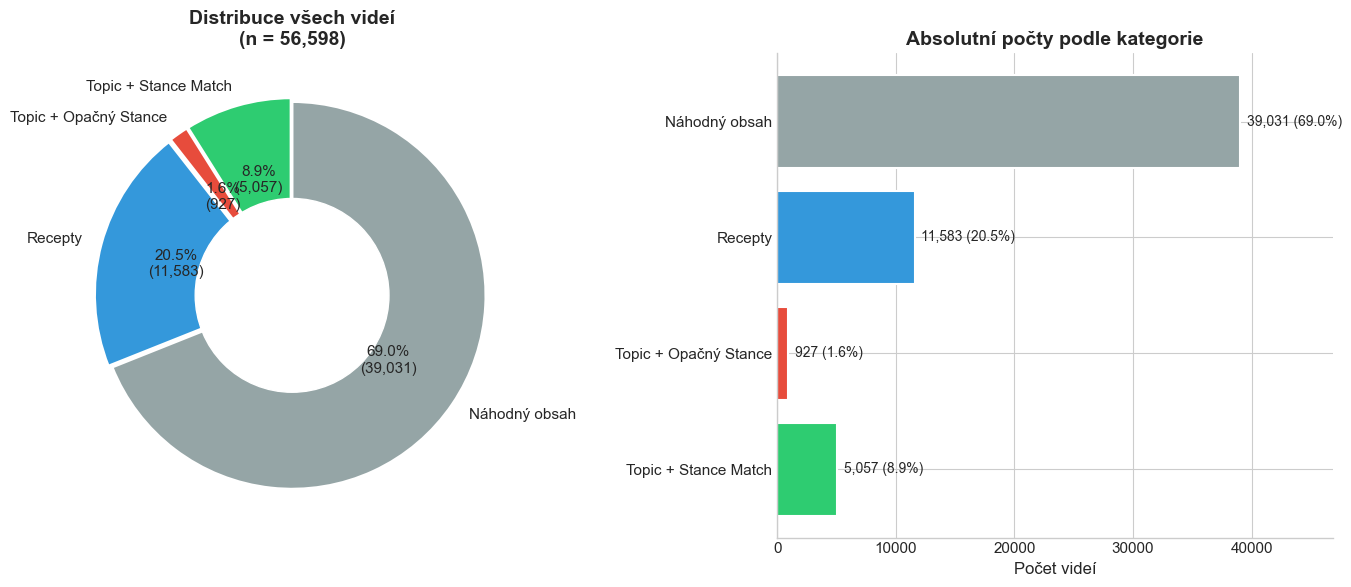

In [31]:
# Výpočet kategorií
total = len(df)
categories = {
    'Topic + Stance Match': df['is_topic_stance'].sum(),
    'Topic + Opačný Stance': df['is_topic_opposite'].sum(),
    'Recepty': df['is_recipes'].sum(),
    'Náhodný obsah': df['is_random'].sum()
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Donut chart
colors = [COLORS['topic_stance'], COLORS['topic_opposite'], COLORS['recipes'], COLORS['random']]
wedges, texts, autotexts = axes[0].pie(
    categories.values(), 
    labels=categories.keys(),
    autopct=lambda p: f'{p:.1f}%\n({int(p*total/100):,})',
    colors=colors,
    startangle=90,
    explode=(0.02, 0.02, 0.02, 0),
    wedgeprops={'linewidth': 2, 'edgecolor': 'white'}
)
centre_circle = plt.Circle((0, 0), 0.5, fc='white')
axes[0].add_patch(centre_circle)
axes[0].set_title(f'Distribuce všech videí\n(n = {total:,})', fontweight='bold', fontsize=14)

# Bar chart
bars = axes[1].barh(list(categories.keys()), list(categories.values()), color=colors, edgecolor='white', linewidth=1.5)
axes[1].set_xlabel('Počet videí')
axes[1].set_title('Absolutní počty podle kategorie', fontweight='bold')
for bar, val in zip(bars, categories.values()):
    axes[1].text(val + total*0.01, bar.get_y() + bar.get_height()/2, 
                 f'{val:,} ({val/total*100:.1f}%)', va='center', fontsize=10)
axes[1].set_xlim(0, max(categories.values()) * 1.2)

plt.tight_layout()
plt.savefig('output/01_global_distribution.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## 4.2 Distribuce podle Topic a Stance

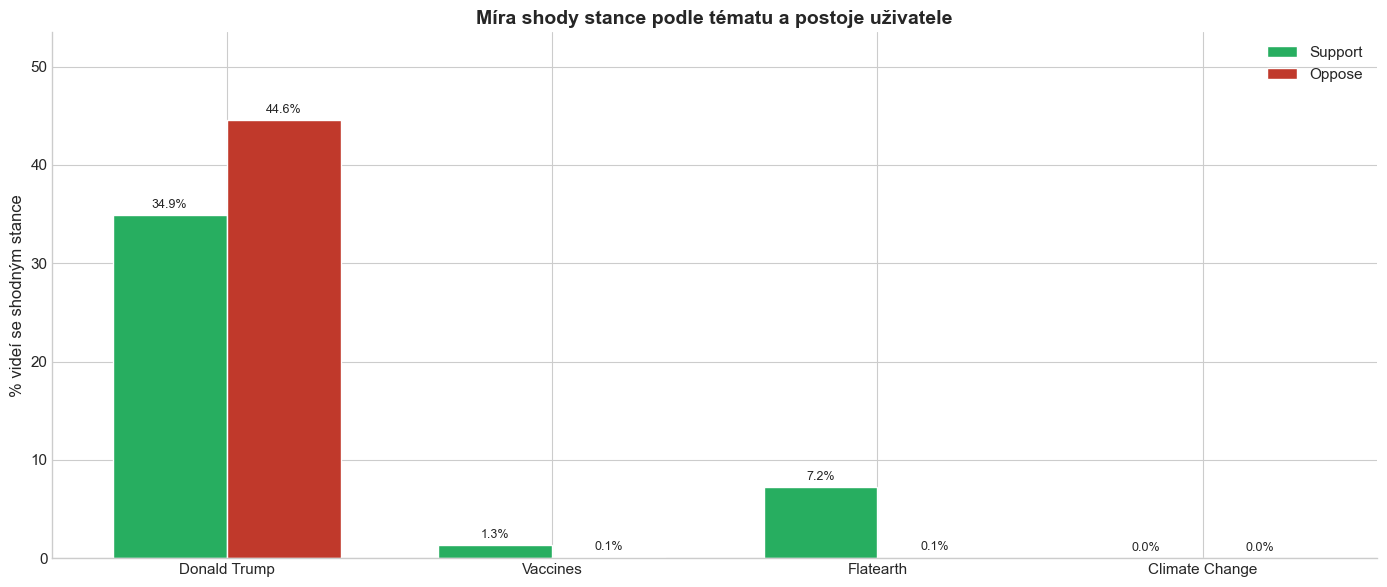

In [32]:
# Agregace podle topic a stance
topic_stance_agg = df.groupby(['topic', 'stance']).agg(
    total_videos=('interaction_number', 'count'),
    topic_match_rate=('predicted_topic_match', 'mean'),
    stance_match_rate=('predicted_stance_match', 'mean'),
    recipes_rate=('is_recipes', 'mean')
).reset_index()
topic_stance_agg = topic_stance_agg[topic_stance_agg['topic'].isin(TARGET_TOPICS)]

fig, ax = plt.subplots(figsize=(14, 6))

# Grouped bar chart
x = np.arange(len(TARGET_TOPICS))
width = 0.35

support_rates = []
oppose_rates = []

for topic in TARGET_TOPICS:
    sup = topic_stance_agg[(topic_stance_agg['topic'] == topic) & (topic_stance_agg['stance'] == 'support')]
    opp = topic_stance_agg[(topic_stance_agg['topic'] == topic) & (topic_stance_agg['stance'] == 'oppose')]
    support_rates.append(sup['stance_match_rate'].values[0] * 100 if len(sup) > 0 else 0)
    oppose_rates.append(opp['stance_match_rate'].values[0] * 100 if len(opp) > 0 else 0)

bars1 = ax.bar(x - width/2, support_rates, width, label='Support', color='#27ae60', edgecolor='white')
bars2 = ax.bar(x + width/2, oppose_rates, width, label='Oppose', color='#c0392b', edgecolor='white')

ax.set_ylabel('% videí se shodným stance')
ax.set_title('Míra shody stance podle tématu a postoje uživatele', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([t.replace('_', ' ').title() for t in TARGET_TOPICS])
ax.legend()
ax.set_ylim(0, max(max(support_rates), max(oppose_rates)) * 1.2)

# Přidání hodnot nad sloupce
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.1f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('output/02_topic_stance_comparison.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

---
# 5. ANALÝZA ALGORITMICKÉ "BUBLINY"
---

## 5.1 Vývoj personalizace v průběhu session (Sliding Window)

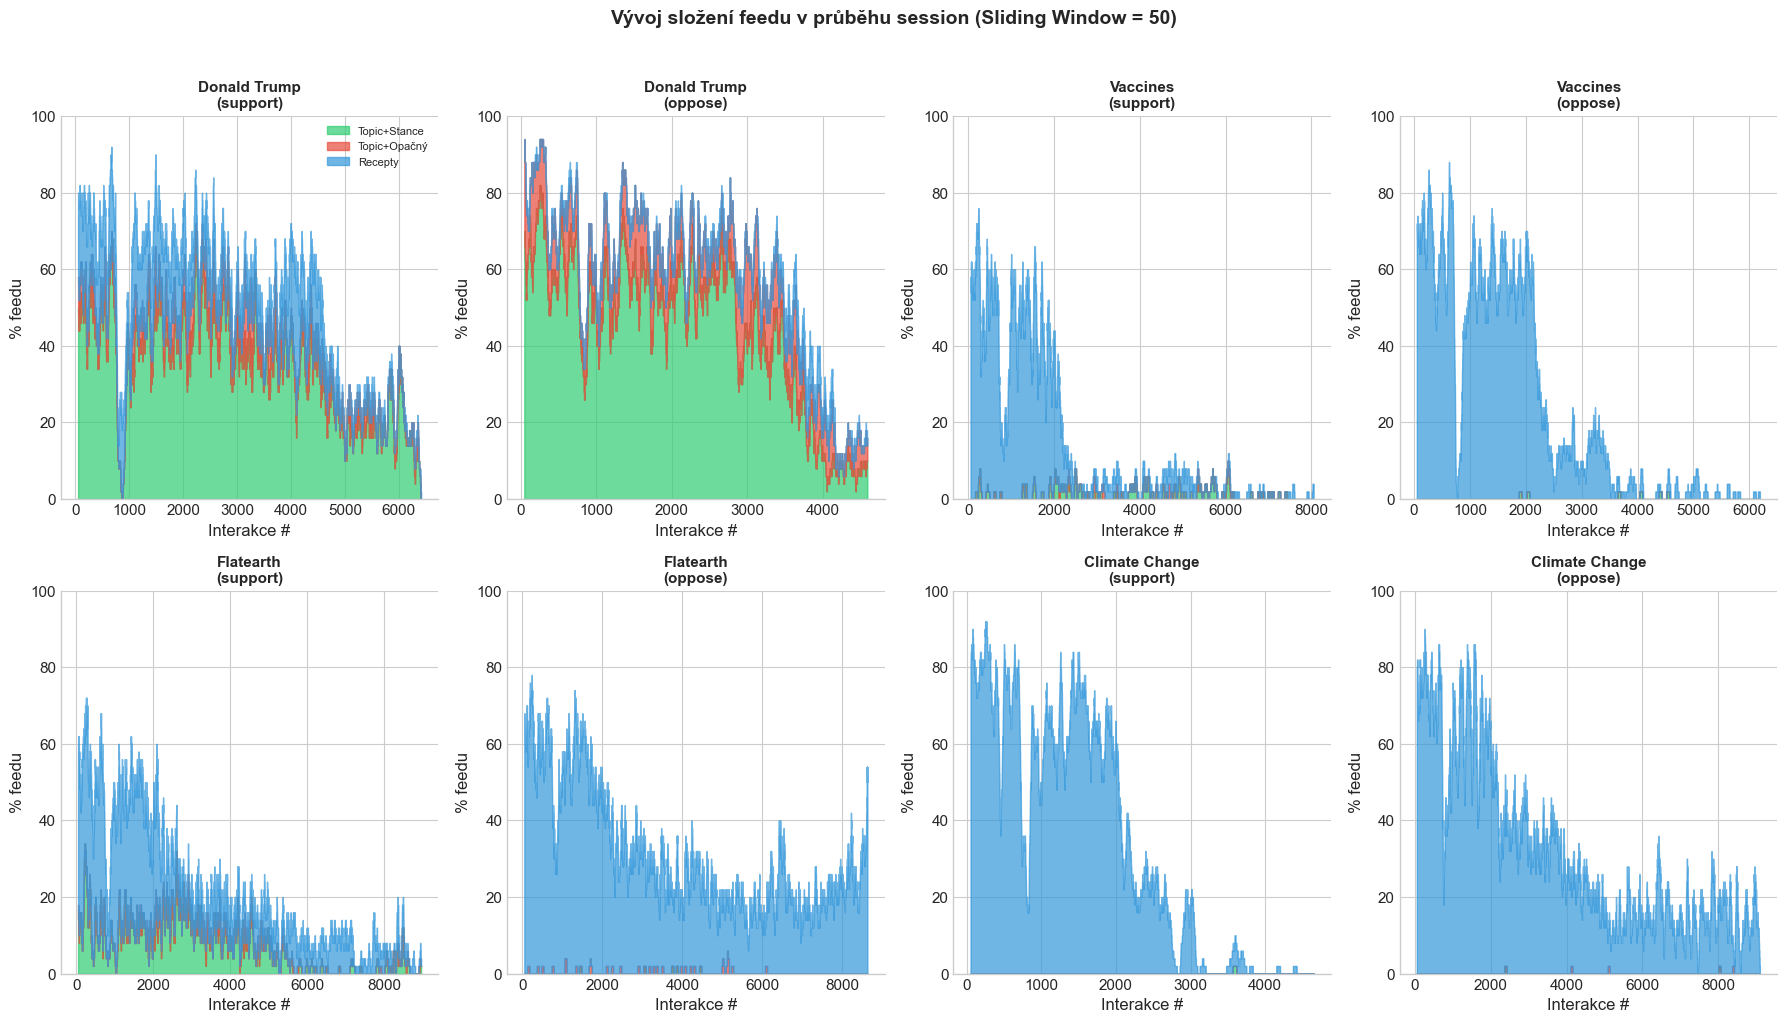

In [33]:
WINDOW = 50

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

plot_idx = 0
for topic in TARGET_TOPICS:
    for stance in TARGET_STANCES:
        label = f"{topic} | {stance}"
        subset = df[df['user_id'].str.contains(label, regex=False)]
        
        if subset.empty:
            continue
        
        user_df = subset.sort_values('interaction_number').reset_index(drop=True)
        
        rolling = user_df[['is_topic_stance', 'is_topic_opposite', 'is_recipes', 'is_random']].rolling(WINDOW).mean() * 100
        
        ax = axes[plot_idx]
        ax.fill_between(rolling.index, 0, rolling['is_topic_stance'], alpha=0.7, label='Topic+Stance', color=COLORS['topic_stance'])
        ax.fill_between(rolling.index, rolling['is_topic_stance'], 
                        rolling['is_topic_stance'] + rolling['is_topic_opposite'], 
                        alpha=0.7, label='Topic+Opačný', color=COLORS['topic_opposite'])
        ax.fill_between(rolling.index, rolling['is_topic_stance'] + rolling['is_topic_opposite'],
                        rolling['is_topic_stance'] + rolling['is_topic_opposite'] + rolling['is_recipes'],
                        alpha=0.7, label='Recepty', color=COLORS['recipes'])
        
        ax.set_title(f"{topic.replace('_', ' ').title()}\n({stance})", fontsize=11)
        ax.set_xlabel('Interakce #')
        ax.set_ylabel('% feedu')
        ax.set_ylim(0, 100)
        
        if plot_idx == 0:
            ax.legend(loc='upper right', fontsize=8)
        
        plot_idx += 1

plt.suptitle(f'Vývoj složení feedu v průběhu session (Sliding Window = {WINDOW})', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('output/03_sliding_window_all.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## 5.2 Uzavírání "bubliny" - kumulativní trend

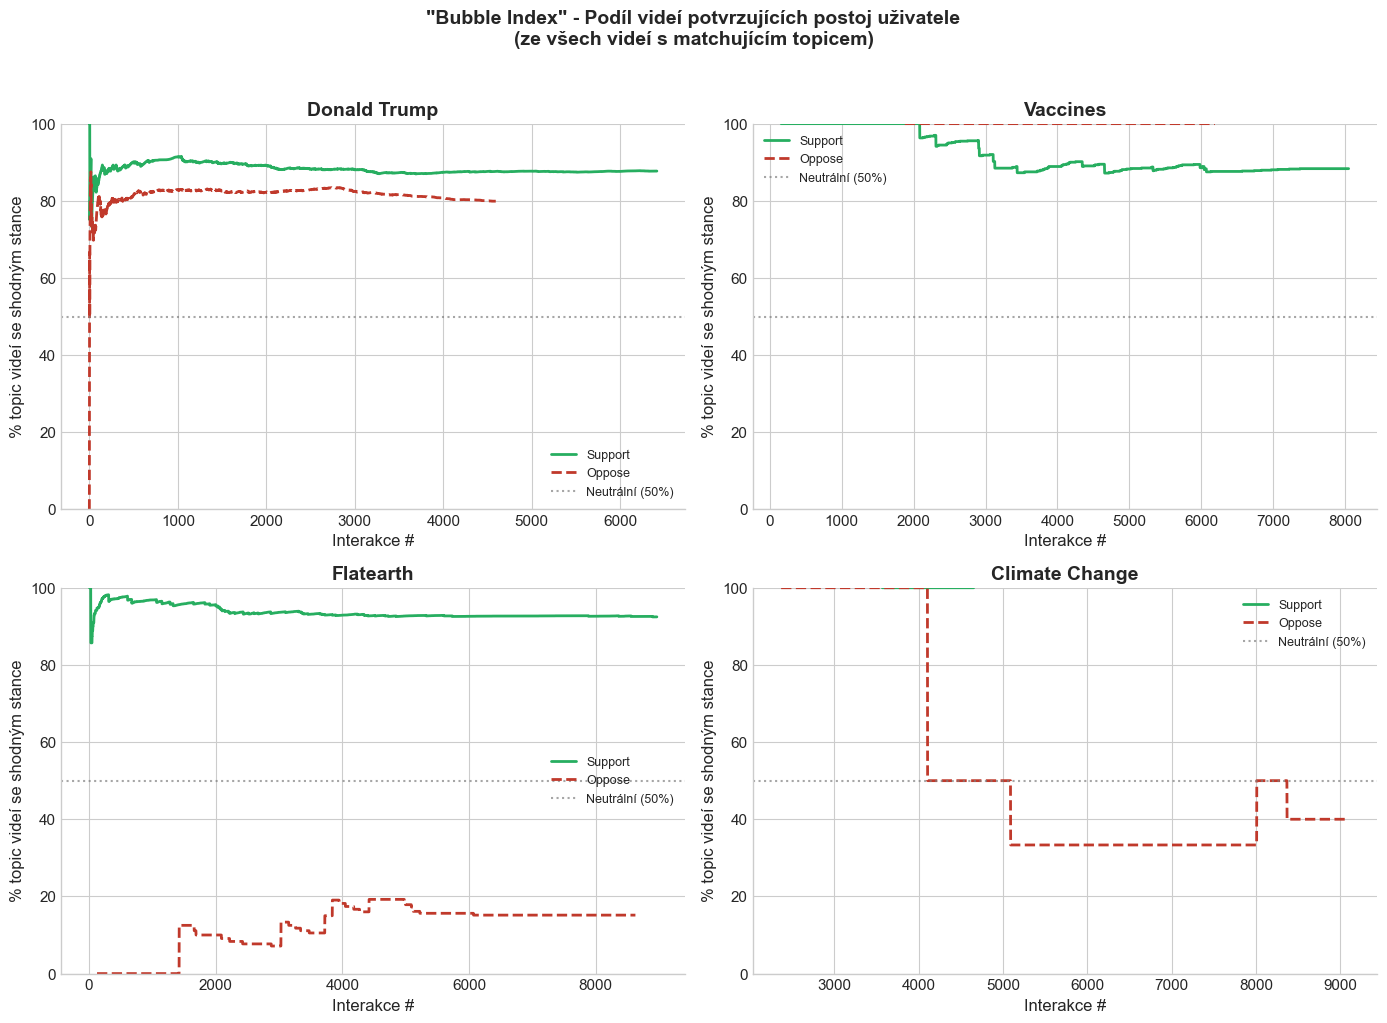

In [34]:
# Analýza jak se mění poměr matching vs opposing stance v čase
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, topic in enumerate(TARGET_TOPICS):
    ax = axes[idx]
    
    for stance, color, ls in [('support', '#27ae60', '-'), ('oppose', '#c0392b', '--')]:
        label = f"{topic} | {stance}"
        subset = df[df['user_id'].str.contains(label, regex=False)]
        
        if subset.empty:
            continue
        
        user_df = subset.sort_values('interaction_number').reset_index(drop=True)
        
        # Kumulativní průměr stance match
        cumulative_stance = user_df['is_topic_stance'].expanding().mean() * 100
        cumulative_opposite = user_df['is_topic_opposite'].expanding().mean() * 100
        
        # Poměr matching / (matching + opposing) - "bubble index"
        topic_videos = user_df['predicted_topic_match'].expanding().sum()
        stance_videos = user_df['is_topic_stance'].expanding().sum()
        bubble_ratio = (stance_videos / topic_videos.replace(0, np.nan)) * 100
        
        ax.plot(user_df.index, bubble_ratio, label=f'{stance.title()}', color=color, linestyle=ls, linewidth=2)
    
    ax.axhline(y=50, color='gray', linestyle=':', alpha=0.7, label='Neutrální (50%)')
    ax.set_title(f"{topic.replace('_', ' ').title()}", fontweight='bold')
    ax.set_xlabel('Interakce #')
    ax.set_ylabel('% topic videí se shodným stance')
    ax.set_ylim(0, 100)
    ax.legend(loc='best', fontsize=9)

plt.suptitle('"Bubble Index" - Podíl videí potvrzujících postoj uživatele\n(ze všech videí s matchujícím topicem)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('output/04_bubble_index.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

---
# 6. ANALÝZA INTERAKCÍ
---

## 6.1 Heatmapa: Typ interakce × Kategorie videa

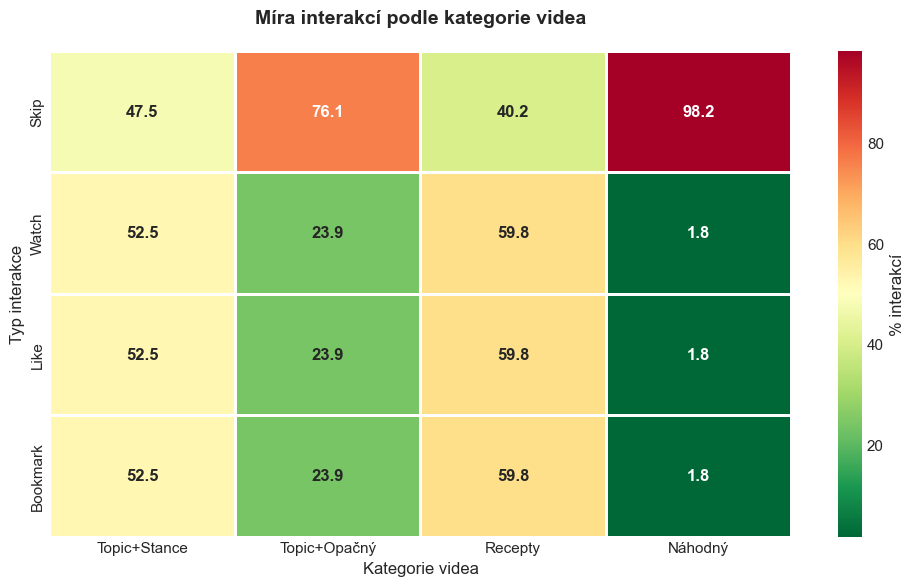

In [35]:
# Vytvoření kategorie videa
def get_video_category(row):
    if row['is_topic_stance']:
        return 'Topic+Stance'
    elif row['is_topic_opposite']:
        return 'Topic+Opačný'
    elif row['is_recipes']:
        return 'Recepty'
    else:
        return 'Náhodný'

df['video_category'] = df.apply(get_video_category, axis=1)

# Interakce matice
interaction_types = ['video_action_skip', 'video_action_watch', 'video_action_like', 'video_action_bookmark']
categories = ['Topic+Stance', 'Topic+Opačný', 'Recepty', 'Náhodný']

heatmap_data = []
for action in interaction_types:
    row = []
    for cat in categories:
        subset = df[df['video_category'] == cat]
        rate = subset[action].mean() * 100 if len(subset) > 0 else 0
        row.append(rate)
    heatmap_data.append(row)

heatmap_df = pd.DataFrame(heatmap_data, 
                          index=['Skip', 'Watch', 'Like', 'Bookmark'],
                          columns=categories)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(heatmap_df, annot=True, fmt='.1f', cmap='RdYlGn_r', 
            linewidths=2, linecolor='white',
            cbar_kws={'label': '% interakcí'}, ax=ax,
            annot_kws={'size': 12, 'weight': 'bold'})
ax.set_title('Míra interakcí podle kategorie videa', fontweight='bold', fontsize=14, pad=20)
ax.set_ylabel('Typ interakce')
ax.set_xlabel('Kategorie videa')

plt.tight_layout()
plt.savefig('output/05_interaction_heatmap.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## 6.2 Engagement Funnel: Watch → Like → Bookmark

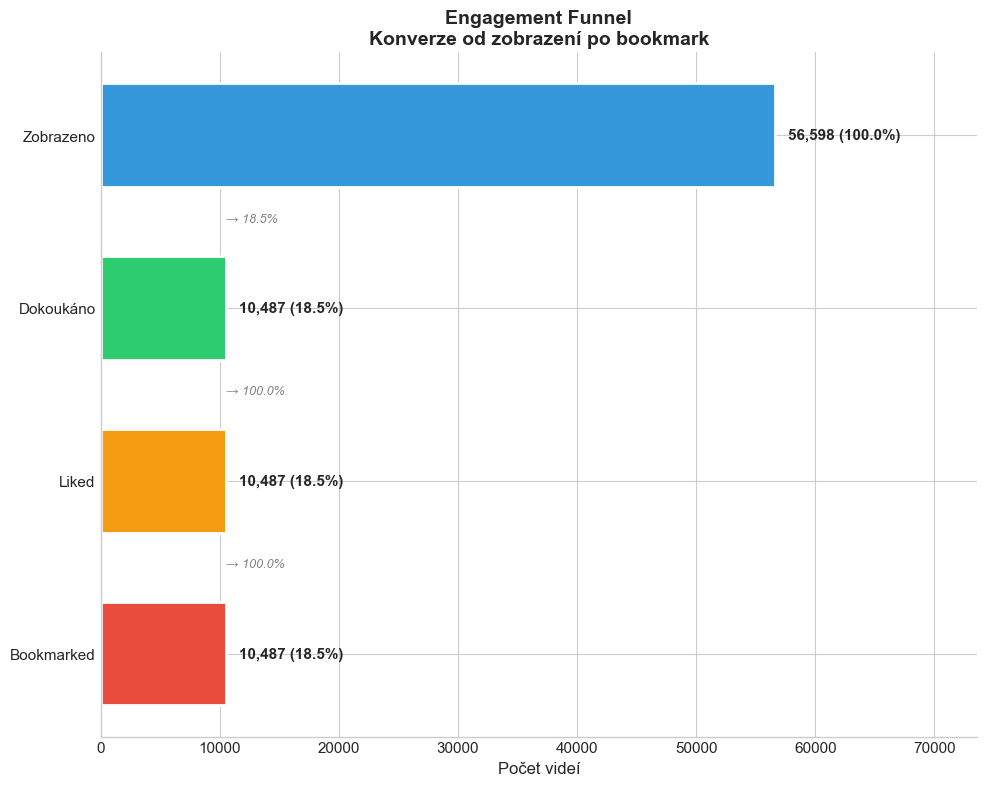

In [36]:
# Funnel analýza
total_videos = len(df)
watched = df['video_action_watch'].sum()
liked = df['video_action_like'].sum()
bookmarked = df['video_action_bookmark'].sum()

funnel_data = {
    'Zobrazeno': total_videos,
    'Dokoukáno': watched,
    'Liked': liked,
    'Bookmarked': bookmarked
}

fig, ax = plt.subplots(figsize=(10, 8))

stages = list(funnel_data.keys())
values = list(funnel_data.values())
percentages = [v/total_videos*100 for v in values]

# Horizontální funnel
colors_funnel = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c']
y_positions = range(len(stages)-1, -1, -1)

bars = ax.barh(y_positions, values, color=colors_funnel, edgecolor='white', linewidth=2, height=0.6)

for i, (bar, stage, val, pct) in enumerate(zip(bars, stages, values, percentages)):
    ax.text(val + total_videos*0.02, bar.get_y() + bar.get_height()/2,
            f'{val:,} ({pct:.1f}%)', va='center', fontsize=11, fontweight='bold')

ax.set_yticks(y_positions)
ax.set_yticklabels(stages)
ax.set_xlabel('Počet videí')
ax.set_title('Engagement Funnel\nKonverze od zobrazení po bookmark', fontweight='bold', fontsize=14)
ax.set_xlim(0, total_videos * 1.3)

# Konverzní šipky
for i in range(len(values)-1):
    if values[i] > 0:
        conv_rate = values[i+1] / values[i] * 100
        ax.annotate(f'→ {conv_rate:.1f}%', 
                    xy=(values[i+1], y_positions[i+1] + 0.5),
                    fontsize=9, color='gray', style='italic')

plt.tight_layout()
plt.savefig('output/06_engagement_funnel.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## 6.3 Doba sledování vs. Délka videa

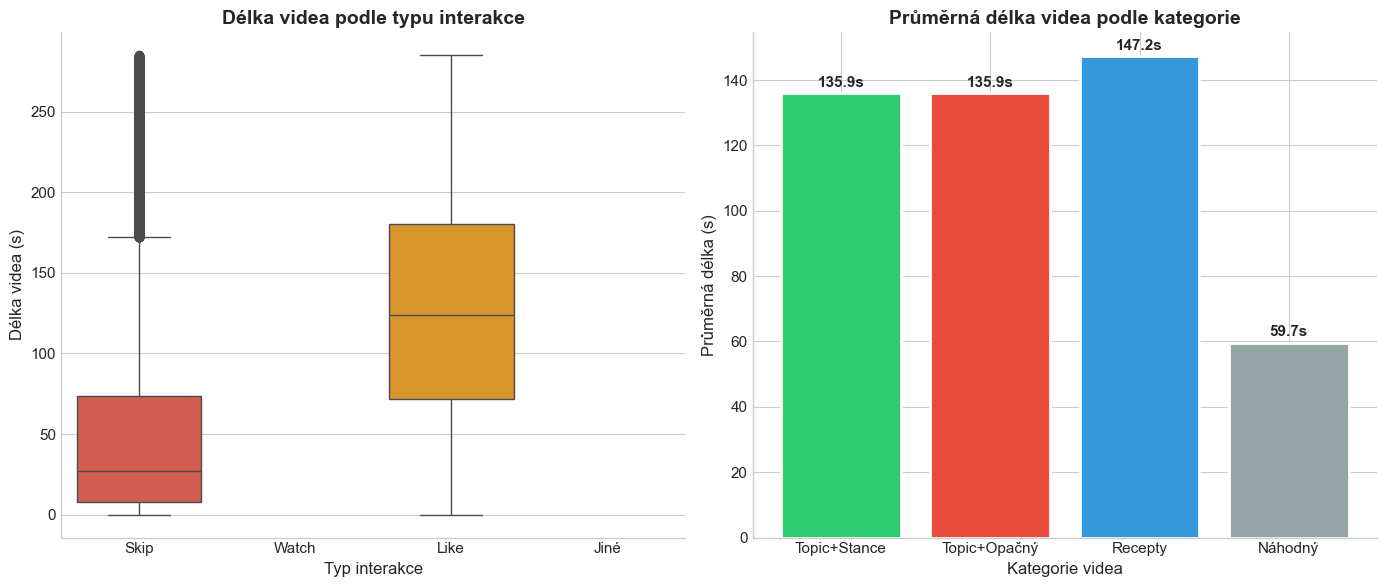

In [37]:
# Analýza délky videí podle kategorie a akce
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Box plot - délka videa podle akce
df_actions = df.copy()
df_actions['action'] = 'Jiné'
df_actions.loc[df_actions['video_action_skip'] == True, 'action'] = 'Skip'
df_actions.loc[df_actions['video_action_watch'] == True, 'action'] = 'Watch'
df_actions.loc[df_actions['video_action_like'] == True, 'action'] = 'Like'

# Filtrování extrémních hodnot
df_plot = df_actions[df_actions['video_time_duration'] < df_actions['video_time_duration'].quantile(0.95)]

order = ['Skip', 'Watch', 'Like', 'Jiné']
colors_box = ['#e74c3c', '#2ecc71', '#f39c12', '#95a5a6']

sns.boxplot(data=df_plot, x='action', y='video_time_duration', order=order, palette=colors_box, ax=axes[0])
axes[0].set_xlabel('Typ interakce')
axes[0].set_ylabel('Délka videa (s)')
axes[0].set_title('Délka videa podle typu interakce', fontweight='bold')

# Průměrná délka podle kategorie
avg_duration = df.groupby('video_category')['video_time_duration'].mean().reindex(categories)
bars = axes[1].bar(avg_duration.index, avg_duration.values, 
                   color=[COLORS['topic_stance'], COLORS['topic_opposite'], COLORS['recipes'], COLORS['random']],
                   edgecolor='white', linewidth=2)

for bar, val in zip(bars, avg_duration.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 1, f'{val:.1f}s', 
                 ha='center', va='bottom', fontweight='bold')

axes[1].set_xlabel('Kategorie videa')
axes[1].set_ylabel('Průměrná délka (s)')
axes[1].set_title('Průměrná délka videa podle kategorie', fontweight='bold')

plt.tight_layout()
plt.savefig('output/07_video_duration_analysis.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## 6.4 Rychlost skipování - histogram

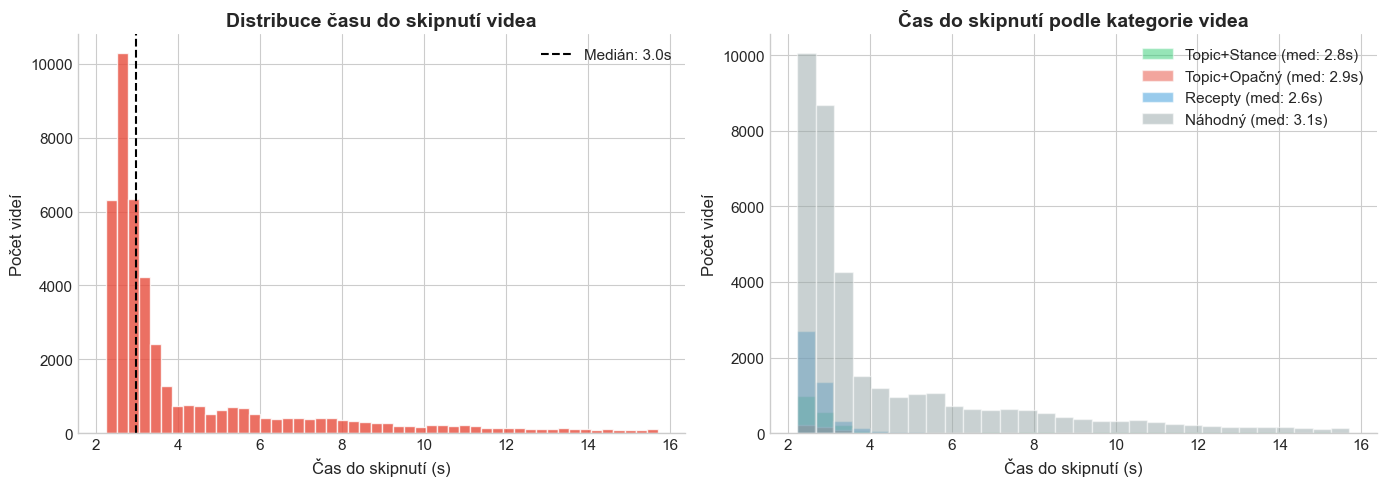

In [38]:
# Analýza času do skipu
if 'video_time_watch_loop_start' in df.columns and 'video_time_watch_loop_end' in df.columns:
    df_skip = df[df['video_action_skip'] == True].copy()

    # Výpočet času sledování před skipem (v sekundách)
    # Použijeme původní timestamp sloupce (jsou float/int - unix timestamp)
    df_skip['skip_time'] = df_skip['video_time_watch_loop_end'] - df_skip['video_time_watch_loop_start']

    # Filtrování validních hodnot
    df_skip = df_skip[df_skip['skip_time'] > 0]
    df_skip = df_skip[df_skip['skip_time'] < df_skip['skip_time'].quantile(0.95)]

    if len(df_skip) > 0:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # Histogram celkový
        axes[0].hist(df_skip['skip_time'], bins=50, color='#e74c3c', edgecolor='white', alpha=0.8)
        axes[0].axvline(df_skip['skip_time'].median(), color='black', linestyle='--',
                        label=f'Medián: {df_skip["skip_time"].median():.1f}s')
        axes[0].set_xlabel('Čas do skipnutí (s)')
        axes[0].set_ylabel('Počet videí')
        axes[0].set_title('Distribuce času do skipnutí videa', fontweight='bold')
        axes[0].legend()

        # Histogram podle kategorie
        for cat, color in zip(categories, [COLORS['topic_stance'], COLORS['topic_opposite'], COLORS['recipes'], COLORS['random']]):
            subset = df_skip[df_skip['video_category'] == cat]['skip_time']
            if len(subset) > 10:  # Minimálně 10 vzorků pro smysluplný histogram
                axes[1].hist(subset, bins=30, alpha=0.5, label=f'{cat} (med: {subset.median():.1f}s)', color=color)

        axes[1].set_xlabel('Čas do skipnutí (s)')
        axes[1].set_ylabel('Počet videí')
        axes[1].set_title('Čas do skipnutí podle kategorie videa', fontweight='bold')
        axes[1].legend()

        plt.tight_layout()
        plt.savefig('output/08_skip_time_analysis.png', dpi=150, bbox_inches='tight', facecolor='white')
        plt.show()
    else:
        print("Nedostatek dat pro analýzu skipování")
else:
    print("Chybí časová data pro analýzu skipování (video_time_watch_loop_start/end)")

---
# 7. PŘESNOST ALGORITMU
---

## 7.1 Confusion Matrix - Topic & Stance Match

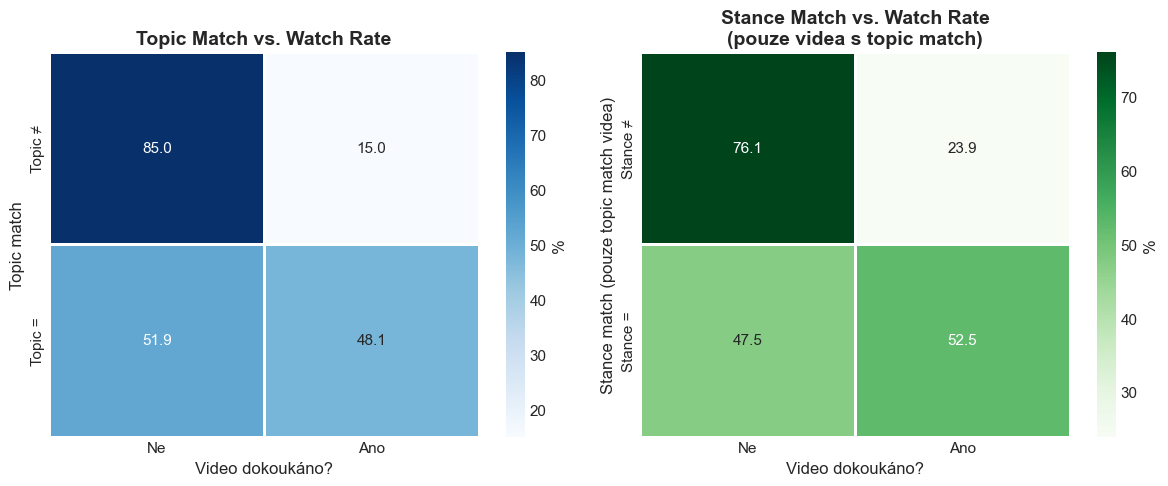

In [39]:
# Confusion matrix style analýza
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Topic match confusion
topic_cm = pd.crosstab(df['predicted_topic_match'], df['video_action_watch'], 
                       normalize='index') * 100
sns.heatmap(topic_cm, annot=True, fmt='.1f', cmap='Blues', ax=axes[0],
            xticklabels=['Ne', 'Ano'], yticklabels=['Topic ≠', 'Topic ='],
            cbar_kws={'label': '%'}, linewidths=2, linecolor='white')
axes[0].set_xlabel('Video dokoukáno?')
axes[0].set_ylabel('Topic match')
axes[0].set_title('Topic Match vs. Watch Rate', fontweight='bold')

# Stance match confusion  
df_topic_only = df[df['predicted_topic_match'] == True]
if len(df_topic_only) > 0:
    stance_cm = pd.crosstab(df_topic_only['predicted_stance_match'], df_topic_only['video_action_watch'],
                            normalize='index') * 100
    sns.heatmap(stance_cm, annot=True, fmt='.1f', cmap='Greens', ax=axes[1],
                xticklabels=['Ne', 'Ano'], yticklabels=['Stance ≠', 'Stance ='],
                cbar_kws={'label': '%'}, linewidths=2, linecolor='white')
    axes[1].set_xlabel('Video dokoukáno?')
    axes[1].set_ylabel('Stance match (pouze topic match videa)')
    axes[1].set_title('Stance Match vs. Watch Rate\n(pouze videa s topic match)', fontweight='bold')

plt.tight_layout()
plt.savefig('output/09_confusion_matrices.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## 7.2 Učení algoritmu - přesnost v průběhu session

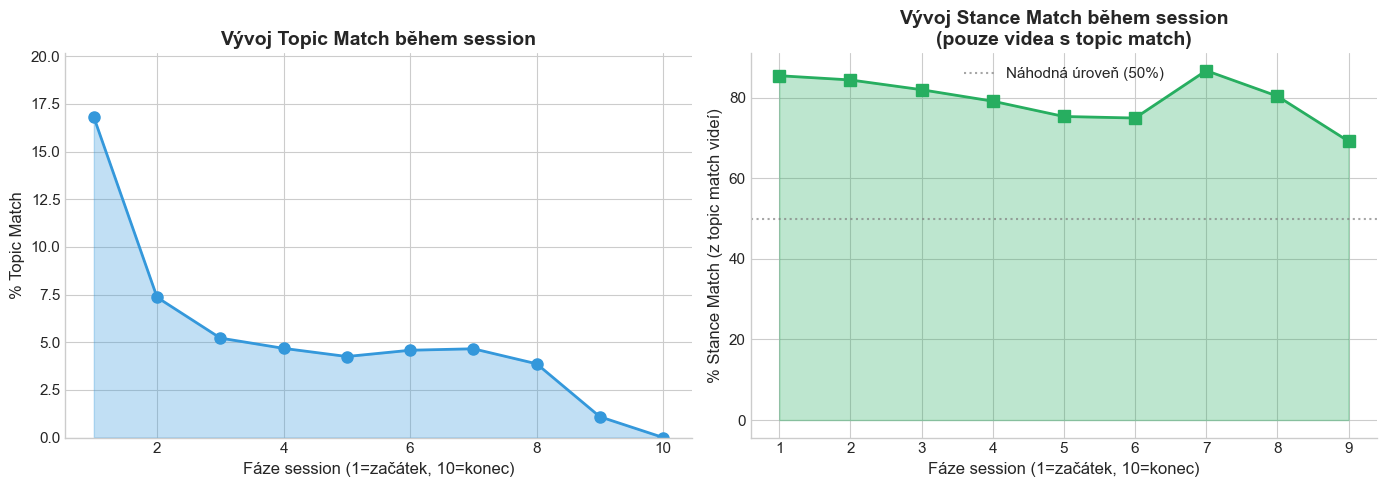

In [40]:
# Analýza zlepšování algoritmu v průběhu session
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Binování interakcí do skupin
df['interaction_bin'] = pd.cut(df['interaction_number'], bins=10, labels=False) + 1

# Topic match rate v průběhu session
topic_progress = df.groupby('interaction_bin')['predicted_topic_match'].mean() * 100
axes[0].plot(topic_progress.index, topic_progress.values, marker='o', linewidth=2, markersize=8, color='#3498db')
axes[0].fill_between(topic_progress.index, topic_progress.values, alpha=0.3, color='#3498db')
axes[0].set_xlabel('Fáze session (1=začátek, 10=konec)')
axes[0].set_ylabel('% Topic Match')
axes[0].set_title('Vývoj Topic Match během session', fontweight='bold')
axes[0].set_ylim(0, max(topic_progress.values) * 1.2)

# Stance match rate v průběhu session (pouze topic match videa)
df_topic_match = df[df['predicted_topic_match'] == True]
if len(df_topic_match) > 0:
    stance_progress = df_topic_match.groupby('interaction_bin')['predicted_stance_match'].mean() * 100
    axes[1].plot(stance_progress.index, stance_progress.values, marker='s', linewidth=2, markersize=8, color='#27ae60')
    axes[1].fill_between(stance_progress.index, stance_progress.values, alpha=0.3, color='#27ae60')
    axes[1].axhline(y=50, color='gray', linestyle=':', alpha=0.7, label='Náhodná úroveň (50%)')
    axes[1].set_xlabel('Fáze session (1=začátek, 10=konec)')
    axes[1].set_ylabel('% Stance Match (z topic match videí)')
    axes[1].set_title('Vývoj Stance Match během session\n(pouze videa s topic match)', fontweight='bold')
    axes[1].legend()

plt.tight_layout()
plt.savefig('output/10_algorithm_learning.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

---
# 8. SROVNÁNÍ TÉMAT
---

## 8.1 Radar chart - Metriky podle tématu

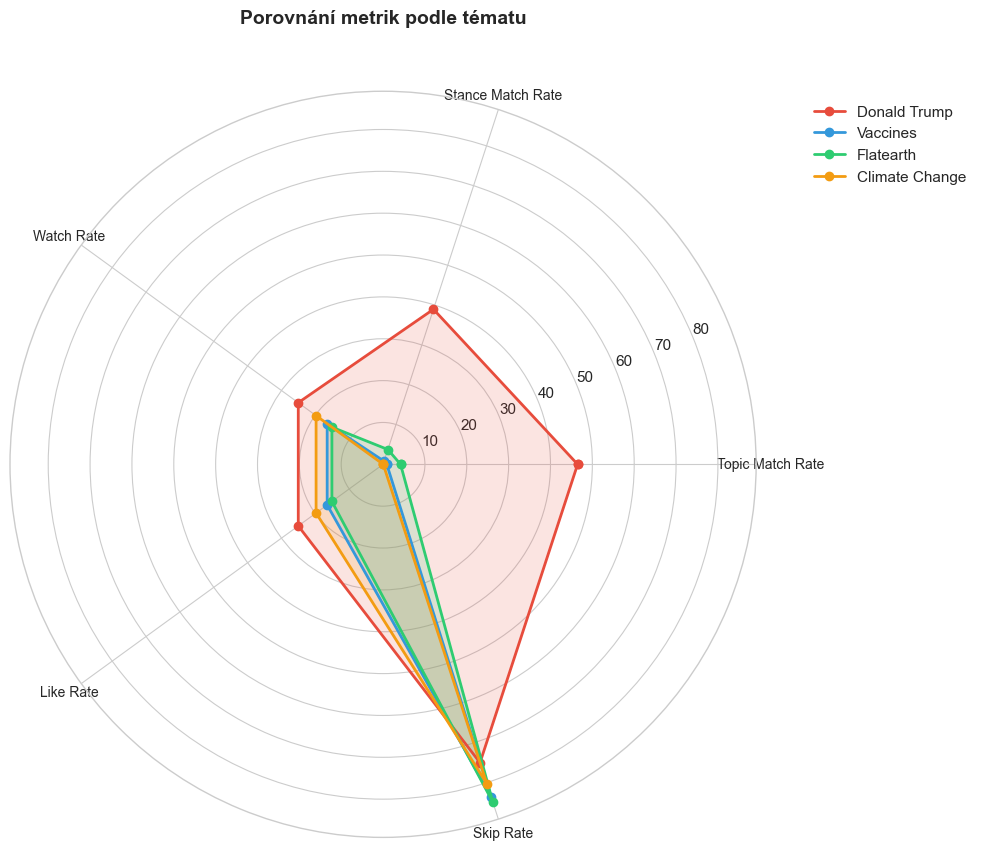

In [41]:
from math import pi

# Výpočet metrik pro každé téma
metrics = []
for topic in TARGET_TOPICS:
    topic_df = df[df['topic'] == topic]
    metrics.append({
        'topic': topic.replace('_', ' ').title(),
        'Topic Match Rate': topic_df['predicted_topic_match'].mean() * 100,
        'Stance Match Rate': topic_df['predicted_stance_match'].mean() * 100,
        'Watch Rate': topic_df['video_action_watch'].mean() * 100,
        'Like Rate': topic_df['video_action_like'].mean() * 100,
        'Skip Rate': topic_df['video_action_skip'].mean() * 100
    })

metrics_df = pd.DataFrame(metrics)

# Radar chart
categories_radar = ['Topic Match Rate', 'Stance Match Rate', 'Watch Rate', 'Like Rate', 'Skip Rate']
N = len(categories_radar)

angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

colors_radar = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

for idx, row in metrics_df.iterrows():
    values = [row[cat] for cat in categories_radar]
    values += values[:1]
    
    ax.plot(angles, values, 'o-', linewidth=2, label=row['topic'], color=colors_radar[idx])
    ax.fill(angles, values, alpha=0.15, color=colors_radar[idx])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories_radar, size=10)
ax.set_title('Porovnání metrik podle tématu', fontweight='bold', size=14, y=1.08)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))

plt.tight_layout()
plt.savefig('output/11_radar_topics.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## 8.2 Topic distribuce ve feedu - stacked area

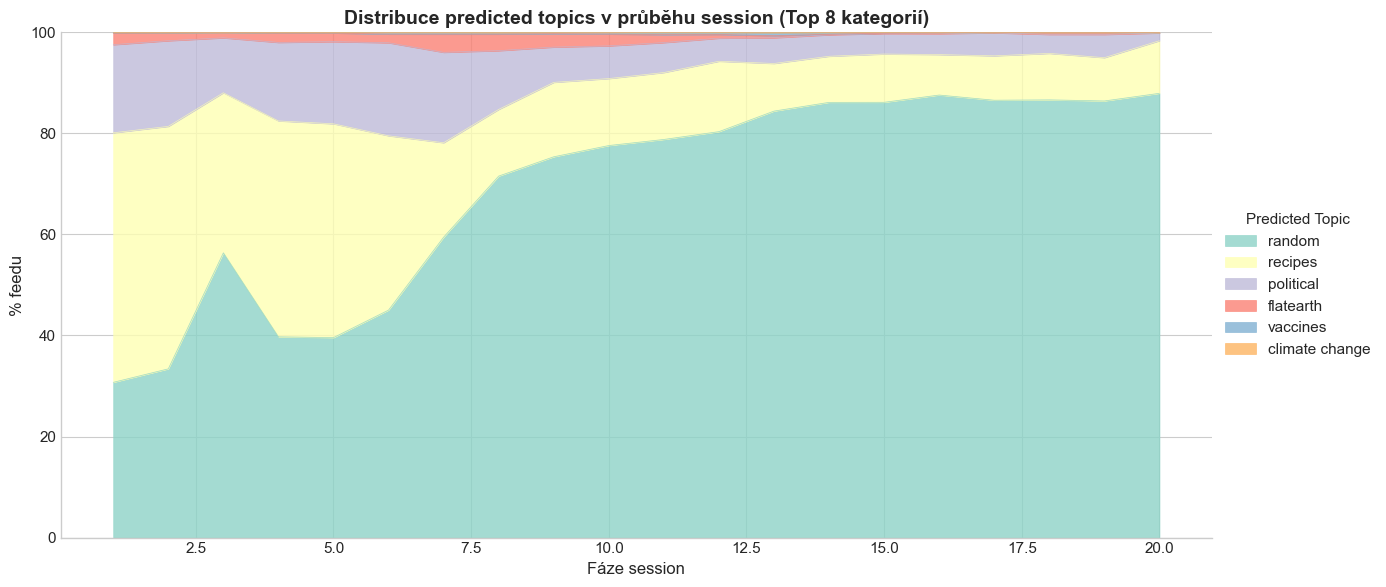

In [42]:
# Predicted topic distribuce v čase pro všechny uživatele
predicted_topics = df['predicted_topic'].unique()

# Vytvoření bins
df['interaction_decile'] = pd.qcut(df['interaction_number'], q=20, labels=False, duplicates='drop') + 1

topic_dist_over_time = df.groupby(['interaction_decile', 'predicted_topic']).size().unstack(fill_value=0)
topic_dist_over_time_pct = topic_dist_over_time.div(topic_dist_over_time.sum(axis=1), axis=0) * 100

# Top 8 témat
top_topics = df['predicted_topic'].value_counts().head(8).index.tolist()
topic_dist_filtered = topic_dist_over_time_pct[top_topics]

fig, ax = plt.subplots(figsize=(14, 6))

topic_dist_filtered.plot(kind='area', stacked=True, ax=ax, alpha=0.8, linewidth=0.5)

ax.set_xlabel('Fáze session')
ax.set_ylabel('% feedu')
ax.set_title('Distribuce predicted topics v průběhu session (Top 8 kategorií)', fontweight='bold')
ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), title='Predicted Topic')
ax.set_ylim(0, 100)

plt.tight_layout()
plt.savefig('output/12_topic_distribution_over_time.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

---
# 9. DEMOGRAFICKÁ ANALÝZA
---

## 9.1 Engagement podle pohlaví a tématu

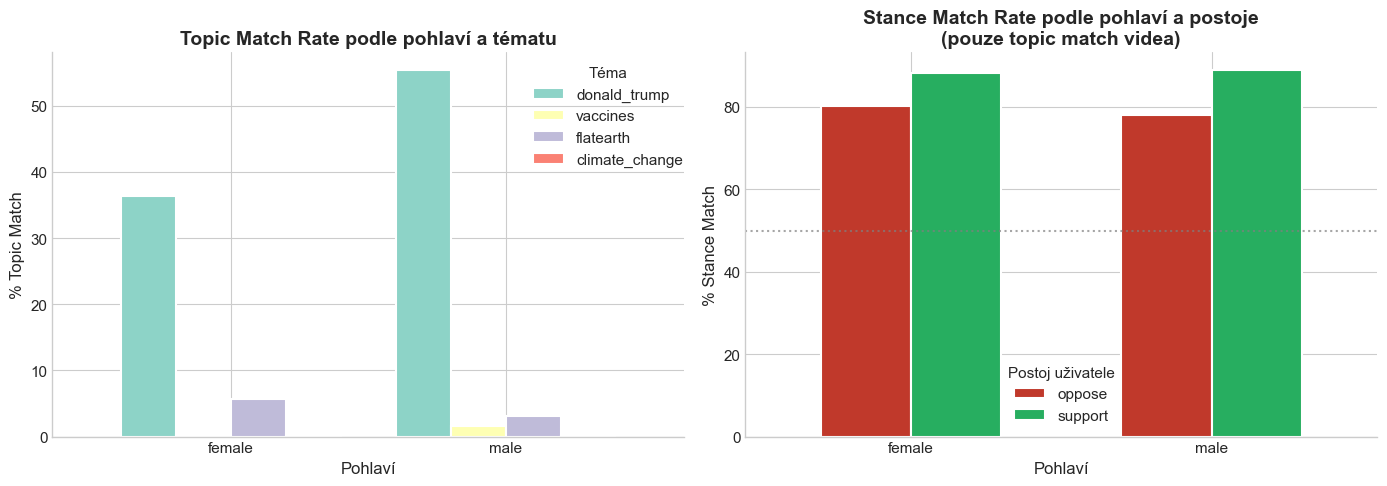

In [43]:
# Gender analýza
if 'gender' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Topic match podle gender
    gender_topic = df.groupby(['gender', 'topic'])['predicted_topic_match'].mean().unstack() * 100
    gender_topic = gender_topic[TARGET_TOPICS]
    
    gender_topic.plot(kind='bar', ax=axes[0], width=0.8, edgecolor='white', linewidth=1.5)
    axes[0].set_xlabel('Pohlaví')
    axes[0].set_ylabel('% Topic Match')
    axes[0].set_title('Topic Match Rate podle pohlaví a tématu', fontweight='bold')
    axes[0].legend(title='Téma', bbox_to_anchor=(1.02, 1))
    axes[0].tick_params(axis='x', rotation=0)
    
    # Stance match podle gender
    gender_stance = df[df['predicted_topic_match'] == True].groupby(['gender', 'stance'])['predicted_stance_match'].mean().unstack() * 100
    
    colors_stance = ['#c0392b', '#27ae60']
    gender_stance.plot(kind='bar', ax=axes[1], color=colors_stance, width=0.6, edgecolor='white', linewidth=1.5)
    axes[1].set_xlabel('Pohlaví')
    axes[1].set_ylabel('% Stance Match')
    axes[1].set_title('Stance Match Rate podle pohlaví a postoje\n(pouze topic match videa)', fontweight='bold')
    axes[1].legend(title='Postoj uživatele')
    axes[1].tick_params(axis='x', rotation=0)
    axes[1].axhline(y=50, color='gray', linestyle=':', alpha=0.7)
    
    plt.tight_layout()
    plt.savefig('output/13_gender_analysis.png', dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()

---
# 10. SOUHRN A STATISTIKY
---

In [44]:
# Souhrnná tabulka
summary_stats = []

for topic in TARGET_TOPICS:
    for stance in TARGET_STANCES:
        subset = df[(df['topic'] == topic) & (df['stance'] == stance)]
        if len(subset) > 0:
            summary_stats.append({
                'Téma': topic.replace('_', ' ').title(),
                'Postoj': stance.title(),
                'Počet videí': len(subset),
                'Topic Match %': f"{subset['predicted_topic_match'].mean()*100:.1f}%",
                'Stance Match %': f"{subset['predicted_stance_match'].mean()*100:.1f}%",
                'Watch Rate %': f"{subset['video_action_watch'].mean()*100:.1f}%",
                'Like Rate %': f"{subset['video_action_like'].mean()*100:.1f}%",
                'Skip Rate %': f"{subset['video_action_skip'].mean()*100:.1f}%"
            })

summary_df = pd.DataFrame(summary_stats)

# Stylovaný výstup
print("="*80)
print("SOUHRNNÉ STATISTIKY PODLE TÉMATU A POSTOJE")
print("="*80)
display(summary_df)

# Uložení do CSV
summary_df.to_csv('output/summary_statistics.csv', index=False)
print("\n✓ Statistiky uloženy do output/summary_statistics.csv")

SOUHRNNÉ STATISTIKY PODLE TÉMATU A POSTOJE


,Téma,Postoj,Počet videí,Topic Match %,Stance Match %,Watch Rate %,Like Rate %,Skip Rate %
0,Donald Trump,Support,6415,39.8%,34.9%,21.4%,21.4%,78.6%
1,Donald Trump,Oppose,4594,55.8%,44.6%,30.1%,30.1%,69.9%
2,Vaccines,Support,8051,1.5%,1.3%,13.3%,13.3%,86.7%
3,Vaccines,Oppose,6191,0.1%,0.1%,20.6%,20.6%,79.4%
4,Flatearth,Support,8968,7.8%,7.2%,15.7%,15.7%,84.3%
5,Flatearth,Oppose,8629,0.4%,0.1%,14.5%,14.5%,85.5%
6,Climate Change,Support,4652,0.0%,0.0%,30.1%,30.1%,69.9%
7,Climate Change,Oppose,9098,0.1%,0.0%,14.5%,14.5%,85.5%



✓ Statistiky uloženy do output/summary_statistics.csv


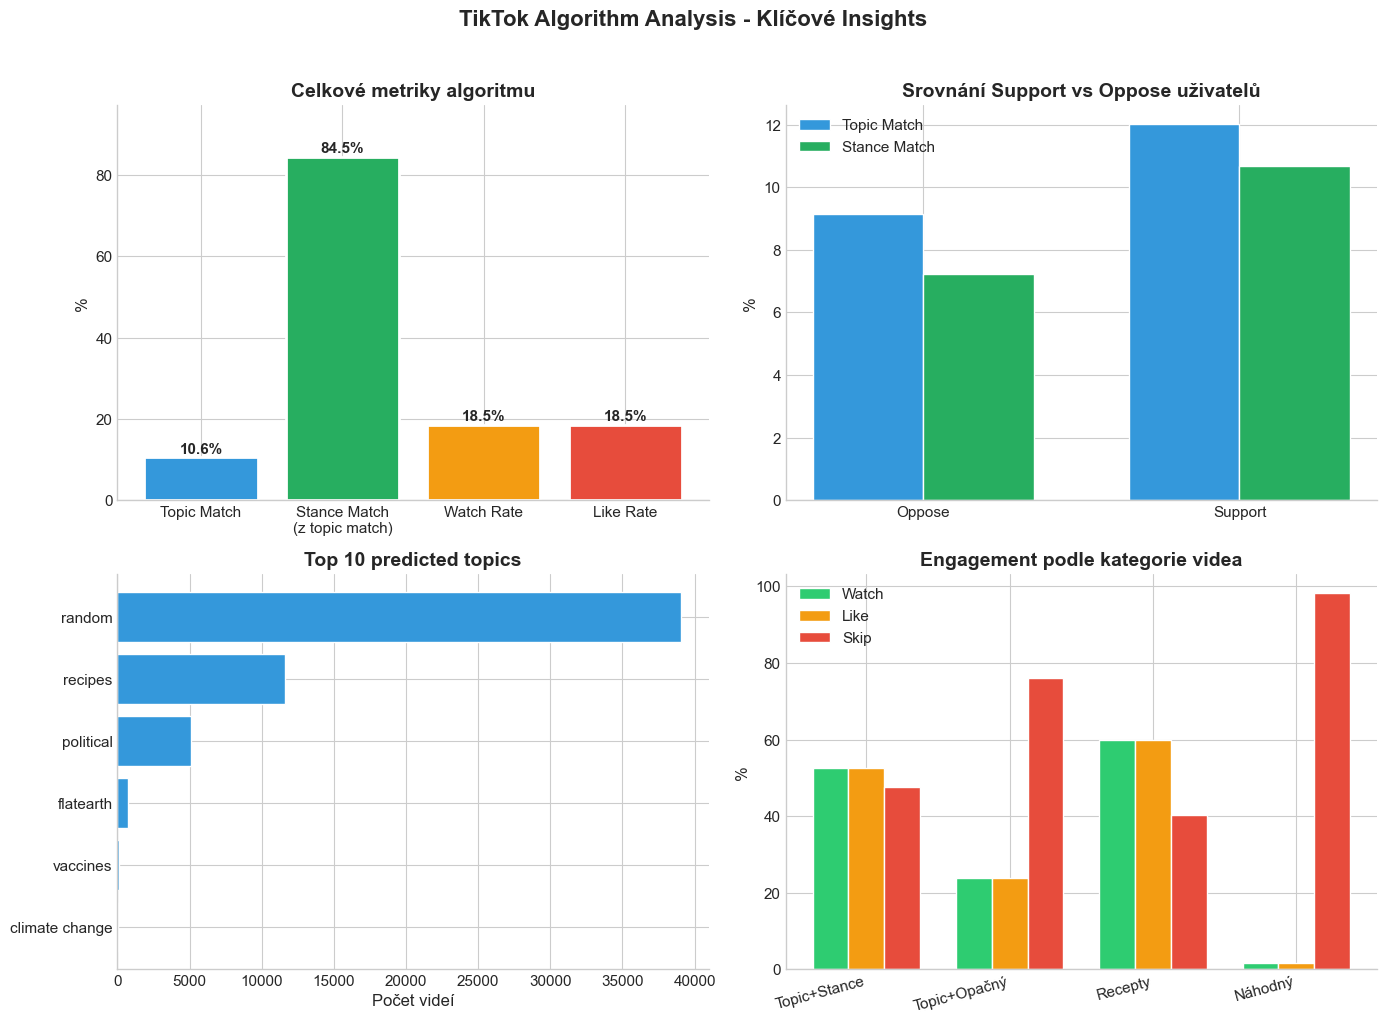


✓ VŠECHNY GRAFY BYLY ULOŽENY DO SLOŽKY 'output/'


In [45]:
# Klíčové insights vizualizace
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Celková úspěšnost algoritmu
overall_metrics = {
    'Topic Match': df['predicted_topic_match'].mean() * 100,
    'Stance Match\n(z topic match)': df[df['predicted_topic_match']==True]['predicted_stance_match'].mean() * 100,
    'Watch Rate': df['video_action_watch'].mean() * 100,
    'Like Rate': df['video_action_like'].mean() * 100
}

bars = axes[0,0].bar(overall_metrics.keys(), overall_metrics.values(), 
                     color=['#3498db', '#27ae60', '#f39c12', '#e74c3c'],
                     edgecolor='white', linewidth=2)
for bar, val in zip(bars, overall_metrics.values()):
    axes[0,0].text(bar.get_x() + bar.get_width()/2, val + 1, f'{val:.1f}%', 
                   ha='center', fontweight='bold')
axes[0,0].set_ylabel('%')
axes[0,0].set_title('Celkové metriky algoritmu', fontweight='bold')
axes[0,0].set_ylim(0, max(overall_metrics.values()) * 1.15)

# 2. Support vs Oppose srovnání
stance_comparison = df.groupby('stance').agg({
    'predicted_topic_match': 'mean',
    'predicted_stance_match': 'mean'
}) * 100

x = np.arange(2)
width = 0.35
bars1 = axes[0,1].bar(x - width/2, stance_comparison['predicted_topic_match'], width, 
                      label='Topic Match', color='#3498db')
bars2 = axes[0,1].bar(x + width/2, stance_comparison['predicted_stance_match'], width,
                      label='Stance Match', color='#27ae60')
axes[0,1].set_xticks(x)
axes[0,1].set_xticklabels(['Oppose', 'Support'])
axes[0,1].set_ylabel('%')
axes[0,1].set_title('Srovnání Support vs Oppose uživatelů', fontweight='bold')
axes[0,1].legend()

# 3. Predicted topic distribuce
topic_counts = df['predicted_topic'].value_counts().head(10)
axes[1,0].barh(topic_counts.index[::-1], topic_counts.values[::-1], color='#3498db', edgecolor='white')
axes[1,0].set_xlabel('Počet videí')
axes[1,0].set_title('Top 10 predicted topics', fontweight='bold')

# 4. Engagement podle video kategorie
category_engagement = df.groupby('video_category').agg({
    'video_action_watch': 'mean',
    'video_action_like': 'mean',
    'video_action_skip': 'mean'
}) * 100
category_engagement = category_engagement.reindex(categories)

x = np.arange(len(categories))
width = 0.25
axes[1,1].bar(x - width, category_engagement['video_action_watch'], width, label='Watch', color='#2ecc71')
axes[1,1].bar(x, category_engagement['video_action_like'], width, label='Like', color='#f39c12')
axes[1,1].bar(x + width, category_engagement['video_action_skip'], width, label='Skip', color='#e74c3c')
axes[1,1].set_xticks(x)
axes[1,1].set_xticklabels(categories, rotation=15, ha='right')
axes[1,1].set_ylabel('%')
axes[1,1].set_title('Engagement podle kategorie videa', fontweight='bold')
axes[1,1].legend()

plt.suptitle('TikTok Algorithm Analysis - Klíčové Insights', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('output/14_key_insights.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print("\n" + "="*80)
print("✓ VŠECHNY GRAFY BYLY ULOŽENY DO SLOŽKY 'output/'")
print("="*80)